# 03 Hierarchical Specialist Pipeline Notebook 

## Objective 

This notebook aims to build a hierarchical document classifier for the given selected classes: 
- invoice, 
- form, 
- resume,
- email, and
- budget. 

As an alternative to a flat five class model, the system organizes its work into two stages: 

### Stage 1: Router 
The first model considers routing each document into one of two general groups: 
1. Group A: invoice, form, and budget
2. Group 2: email and resume 

### Stage 2: Specialists 
Subsequently, a specialist model predicts a final class inside the routed group:
1. Specialist A: invoice vs form vs budget
2. Spcialist B: email vs resume 

## Why use a hierarchy?
When a hierarchical setup is used as by the nature of some classes, some documents are more similar to each other, making it now more intuitive:
- invoice, form, and budget may share structured layouts, numbers, dates, and tables
- email and resume are usually more text-heavy and narrative

This desing may help avoid confusion by permiting each specialist to focus only on a segmented and more coherent subset of classes. 

## Leakage avoidance

To keep the assesment fair and reproducible:
- we use the shared train.csv, val.csv and test.scv
- never change the split
- all vectorizers and preprocessors are fit on train only
- validation is used for design decisions and tuning
- the test set is used only for the final evaluation
- OCR cache is reused when available, and missing OCR is generated only from the requested split files


## 1. Imports, configuratons, paths, and split loading 

In this section we load the OCR configuration from the YAML file, the shared tain/validation/test splits, and the fixed class order used by the whole project. We also create the grouped labels needed for the hierarchical router: 
1. Group A: invoice, form, budget 
2. Group B: email, resume

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification
src exists: True


In [2]:
import pandas as pd
from src.config import load_ocr_config
from src.ocr_engine import ocr_batch, load_ocr_text
from src.evaluation import (
    compute_metrics,
    classification_report_df,
    confusion_matrix_df,
    plot_confusion_matrix,
)
from src.models_hierarchical import (
    build_stage1_frame,
    build_error_propagation_table,
    format_prediction_output,
)

In [3]:
#paths and config
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_INTERIM_OCR = PROJECT_ROOT / "data" / "interim" / "ocr"
OUTPUT_PRED = PROJECT_ROOT / "outputs" / "predictions"
REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for p in [OUTPUT_PRED, REPORT_TABLES, REPORT_FIGURES, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

cfg = load_ocr_config(CONFIG_PATH)

CLASS_ORDER = ["invoice", "form", "resume", "email", "budget"]

print("Config loaded from:", CONFIG_PATH)
print("Processed data folder:", DATA_PROCESSED)
print("OCR folder:", DATA_INTERIM_OCR)

Config loaded from: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/configs/config.yaml
Processed data folder: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/processed
OCR folder: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/interim/ocr


In [4]:
# load shared splits
train_df = pd.read_csv(DATA_PROCESSED / "train.csv")
val_df = pd.read_csv(DATA_PROCESSED / "val.csv")
test_df = pd.read_csv(DATA_PROCESSED / "test.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (8777, 12)
Val shape: (1882, 12)
Test shape: (1881, 12)


In [5]:
# add stage 1 grouped labels
train_df = build_stage1_frame(train_df)
val_df = build_stage1_frame(val_df)
test_df = build_stage1_frame(test_df)

In [6]:
# preview the data 
display(train_df.head())

,doc_id,file_path,relative_path,class_name,split_original,source_folder,file_ext,width,height,read_error,hash_md5,split,group_label
0,doc_00000000,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test/form/2070260358.tif,form,test,test/form,.tif,754.0,1000.0,NaN,495631ee73bd149fbedd791631d63b4f,train,group_a
1,doc_00000001,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test/form/2028608875_2028608881.tif,form,test,test/form,.tif,785.0,1000.0,NaN,20de1efa3dd7e1a06ed5b313a3a5a62c,train,group_a
2,doc_00000002,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test/form/2028706790.tif,form,test,test/form,.tif,777.0,1000.0,NaN,2c4660b2409aa844ba5396a5c222d3b7,train,group_a
3,doc_00000003,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test/form/522754652+-4654.tif,form,test,test/form,.tif,754.0,1000.0,NaN,c3890b15e45d3d6ad0f4d4f50e8cdf5d,train,group_a
4,doc_00000004,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test/form/2024964183.tif,form,test,test/form,.tif,777.0,1000.0,NaN,4c35ff8e492f373ae046a34ea7dc804b,train,group_a


In [7]:
# check original class balance
print("Train class distribution")
display(train_df["class_name"].value_counts().sort_index())

print("\nValidation class distribution")
display(val_df["class_name"].value_counts().sort_index())

print("\nTest class distribution")
display(test_df["class_name"].value_counts().sort_index())

Train class distribution


class_name
budget     1753
email      1761
form       1754
invoice    1734
resume     1775
Name: count, dtype: int64


Validation class distribution


class_name
budget     376
email      378
form       376
invoice    371
resume     381
Name: count, dtype: int64


Test class distribution


class_name
budget     376
email      377
form       376
invoice    372
resume     380
Name: count, dtype: int64

#### Interpretation of original class balance
From the outputs, it can be seen that the class distribution is very balanced across the train, validation and test splits. 
Each of the five document classes has a very close number of examples, which is crucial for fairness in model training and evaluation. 

This kind of balance minimizes the risk of obtaining strong results caused by class imbalance rather than genuine model performance. 
It also means that accuracy and macro F1 can be interpreted more reliably, since no single class dominates the dataset.

In [8]:
# check grouped balance for stage 1
print("Stage-1 group distribution (train)")
display(train_df["group_label"].value_counts())

print("\nStage-1 group distribution (val)")
display(val_df["group_label"].value_counts())

print("\nStage-1 group distribution (test)")
display(test_df["group_label"].value_counts())

Stage-1 group distribution (train)


group_label
group_a    5241
group_b    3536
Name: count, dtype: int64


Stage-1 group distribution (val)


group_label
group_a    1123
group_b     759
Name: count, dtype: int64


Stage-1 group distribution (test)


group_label
group_a    1124
group_b     757
Name: count, dtype: int64

#### Interpretation of Stage-1 group balance

Subsequent to the grouping for the hierarchical router, reasonable balance can still be observed, although Group A is larger than Group B. 
This slight imbalance is expected whereas Group A is composed of three classes and Group B only two. 


In [9]:
# integrity checks
expected_classes = {"invoice", "form", "resume", "email", "budget"}
expected_groups = {"group_a", "group_b"}

assert set(train_df["class_name"].unique()) == expected_classes
assert set(val_df["class_name"].unique()) == expected_classes
assert set(test_df["class_name"].unique()) == expected_classes

assert set(train_df["group_label"].unique()) == expected_groups
assert set(val_df["group_label"].unique()) == expected_groups
assert set(test_df["group_label"].unique()) == expected_groups

print("All integrity checks passed.")

All integrity checks passed.


In [10]:
# summary table
split_summary = pd.DataFrame({
    "train": train_df["class_name"].value_counts().sort_index(),
    "val": val_df["class_name"].value_counts().sort_index(),
    "test": test_df["class_name"].value_counts().sort_index(),
}).fillna(0).astype(int)

display(split_summary)

,train,val,test
class_name,,,
budget,1753,376,376
email,1761,378,377
form,1754,376,376
invoice,1734,371,372
resume,1775,381,380


## 2. OCR cache audit and path standardization

The basis of the hierarchical pipeline is OCR derived text. Hence, prior to any model training, we need to verify that OCR outputs exist for the documents in each split. 

In this section, we:
- standardize the OCR cahce paths to avoid project-level directories conflicts, 
- measure OCR coverage for train, validation, and test
- identify which documents are still missing OCR


In [11]:
# Standardize OCR-related paths to the project root.
cfg.cache_dir = str((PROJECT_ROOT / "data" / "interim" / "ocr").resolve())
cfg.diagnostics_dir = str((PROJECT_ROOT / "outputs" / "ocr_diagnostics").resolve())
cfg.failure_log_path = str((PROJECT_ROOT / "data" / "interim" / "ocr" / "logs" / "ocr_failures.jsonl").resolve())

OCR_ROOT = Path(cfg.cache_dir)

print("OCR root:", OCR_ROOT)
print("Diagnostics dir:", cfg.diagnostics_dir)
print("Failure log path:", cfg.failure_log_path)

OCR root: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/interim/ocr
Diagnostics dir: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/ocr_diagnostics
Failure log path: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/interim/ocr/logs/ocr_failures.jsonl


#### Interpretation of OCR path setup

At this point the OCR configuration is explicitly tied to the project root.  By doing so, we are ensuring that OCR generation, OCR loading, and OCR coverage checks all point to the same cache directory.

This avoids a common notebook issue where relative paths may accidentally resolve inside the `notebooks/` folder instead of the main project folder.

In [12]:
def ocr_files_exist(doc_id: str, ocr_root: Path) -> bool:
    """
    Return True if both the OCR text file and parsed OCR JSON exist for a document.
    """
    doc_id = str(doc_id)
    text_path = ocr_root / "text" / f"{doc_id}.txt"
    parsed_path = ocr_root / "parsed" / f"{doc_id}.json"
    return text_path.exists() and parsed_path.exists()


def audit_ocr_split(df: pd.DataFrame, split_name: str, ocr_root: Path) -> tuple[pd.DataFrame, dict]:
    """
    Check OCR coverage for one split and return:
    - dataframe with an ocr_exists column
    - summary dictionary
    """
    temp = df.copy()
    temp["ocr_exists"] = temp["doc_id"].astype(str).apply(lambda x: ocr_files_exist(x, ocr_root))

    n_total = len(temp)
    n_ready = int(temp["ocr_exists"].sum())
    n_missing = n_total - n_ready
    pct_ready = round(100 * n_ready / n_total, 2) if n_total > 0 else 0.0

    summary = {
        "split": split_name,
        "n_total": n_total,
        "n_ready_ocr": n_ready,
        "n_missing_ocr": n_missing,
        "pct_ready_ocr": pct_ready,
    }

    return temp, summary

In [13]:
train_cov, train_summary = audit_ocr_split(train_df, "train", OCR_ROOT)
val_cov, val_summary = audit_ocr_split(val_df, "val", OCR_ROOT)
test_cov, test_summary = audit_ocr_split(test_df, "test", OCR_ROOT)

ocr_summary = pd.DataFrame([train_summary, val_summary, test_summary])
display(ocr_summary)

,split,n_total,n_ready_ocr,n_missing_ocr,pct_ready_ocr
0,train,8777,8777,0,100.0
1,val,1882,1882,0,100.0
2,test,1881,1881,0,100.0


#### Interpretation of OCR coverage

In the results above, the amount ot each split that already has usable OCR outputs can be observed. In this case, we obtain very positive results as OCR coverage is complete for all the three splits: train, val and test. This means that the dataset is fully prepared for OCR based modelling, meaning that we can shift to loading the cached text and training the hierarchical classifier. 

In [14]:
missing_train = train_cov.loc[
    ~train_cov["ocr_exists"],
    ["doc_id", "file_path", "split", "class_name", "group_label"]
].copy()

missing_val = val_cov.loc[
    ~val_cov["ocr_exists"],
    ["doc_id", "file_path", "split", "class_name", "group_label"]
].copy()

missing_test = test_cov.loc[
    ~test_cov["ocr_exists"],
    ["doc_id", "file_path", "split", "class_name", "group_label"]
].copy()

print("Missing OCR counts")
print("train:", len(missing_train))
print("val:  ", len(missing_val))
print("test: ", len(missing_test))

Missing OCR counts
train: 0
val:   0
test:  0


In [15]:
print("Preview of train documents missing OCR")
display(missing_train.head())

print("\nPreview of validation documents missing OCR")
display(missing_val.head())

print("\nPreview of test documents missing OCR")
display(missing_test.head())

Preview of train documents missing OCR


,doc_id,file_path,split,class_name,group_label



Preview of validation documents missing OCR


,doc_id,file_path,split,class_name,group_label



Preview of test documents missing OCR


,doc_id,file_path,split,class_name,group_label


#### Interpretation of missing OCR documents

These previews show which documents still lack cached OCR outputs, and in this case none. 

Previewing this information is crucial as: 
- it confirms that the coverage audit is working correctly at the document level
- it allows us to generate OCR only for the remaining missing files, instead of rerunning the entire OCR pipeline

This makes the workflow more efficient and keeps the notebook reproducible.

In [16]:
total_text_files = len(list((OCR_ROOT / "text").glob("*.txt"))) if (OCR_ROOT / "text").exists() else 0
total_parsed_files = len(list((OCR_ROOT / "parsed").glob("*.json"))) if (OCR_ROOT / "parsed").exists() else 0

cache_inventory = pd.DataFrame({
    "artifact_type": ["text_files", "parsed_json_files"],
    "count": [total_text_files, total_parsed_files]
})

display(cache_inventory)

,artifact_type,count
0,text_files,12540
1,parsed_json_files,12540


### Generate OCR for Missing Documents: do only if OCR audit shows that some documents are still missing OCR

In [17]:
BUILD_MISSING_TRAIN_OCR = False
BUILD_MISSING_VAL_OCR = False
BUILD_MISSING_TEST_OCR = False

In [18]:
if BUILD_MISSING_TRAIN_OCR and len(missing_train) > 0:
    print("Building missing OCR for train...")
    _ = ocr_batch(
        missing_train[["doc_id", "file_path", "split", "class_name"]],
        cfg=cfg,
        force=False,
        save_diagnostics=False,
        show_progress=True,
    )

if BUILD_MISSING_VAL_OCR and len(missing_val) > 0:
    print("Building missing OCR for validation...")
    _ = ocr_batch(
        missing_val[["doc_id", "file_path", "split", "class_name"]],
        cfg=cfg,
        force=False,
        save_diagnostics=False,
        show_progress=True,
    )

if BUILD_MISSING_TEST_OCR and len(missing_test) > 0:
    print("Building missing OCR for test...")
    _ = ocr_batch(
        missing_test[["doc_id", "file_path", "split", "class_name"]],
        cfg=cfg,
        force=False,
        save_diagnostics=False,
        show_progress=True,
    )

## 3. Load cached OCR text into the dataframes

Now we will be loading the cached OCR text for each document. This section deals with linking every document in the train, validation, and test sets to its OCR text, and performing a small quality check using text length and empty-text counts.

By doing so, the data would we prepared for the Stage 1 router, which will use OCR derived ext as one of its main inputs.


In [19]:
def load_cached_ocr_text(doc_id: str, ocr_root: Path) -> str:
    """
    Load cached OCR text for a document.
    Returns an empty string if the text file is missing.
    """
    doc_id = str(doc_id)
    text_path = ocr_root / "text" / f"{doc_id}.txt"

    if not text_path.exists():
        return ""

    try:
        return text_path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return ""

In [20]:
def attach_ocr_text(df: pd.DataFrame, ocr_root: Path) -> pd.DataFrame:
    """
    Add OCR text and simple OCR text statistics to a dataframe.
    """
    out = df.copy()
    out["ocr_text"] = out["doc_id"].astype(str).apply(lambda x: load_cached_ocr_text(x, ocr_root))
    out["ocr_text"] = out["ocr_text"].fillna("").astype(str)
    out["ocr_text_clean"] = out["ocr_text"].str.strip()
    out["ocr_char_len"] = out["ocr_text_clean"].str.len()
    out["ocr_word_count"] = out["ocr_text_clean"].str.split().str.len()
    out["ocr_is_empty"] = out["ocr_char_len"].eq(0)
    return out

In [21]:
train_df = attach_ocr_text(train_df, OCR_ROOT)
val_df = attach_ocr_text(val_df, OCR_ROOT)
test_df = attach_ocr_text(test_df, OCR_ROOT)

print("OCR text attached successfully.")
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

OCR text attached successfully.
Train shape: (8777, 18)
Val shape: (1882, 18)
Test shape: (1881, 18)


In [22]:
ocr_text_summary = pd.DataFrame([
    {
        "split": "train",
        "n_docs": len(train_df),
        "n_empty_ocr": int(train_df["ocr_is_empty"].sum()),
        "pct_empty_ocr": round(100 * train_df["ocr_is_empty"].mean(), 2),
        "avg_char_len": round(train_df["ocr_char_len"].mean(), 2),
        "avg_word_count": round(train_df["ocr_word_count"].mean(), 2),
    },
    {
        "split": "val",
        "n_docs": len(val_df),
        "n_empty_ocr": int(val_df["ocr_is_empty"].sum()),
        "pct_empty_ocr": round(100 * val_df["ocr_is_empty"].mean(), 2),
        "avg_char_len": round(val_df["ocr_char_len"].mean(), 2),
        "avg_word_count": round(val_df["ocr_word_count"].mean(), 2),
    },
    {
        "split": "test",
        "n_docs": len(test_df),
        "n_empty_ocr": int(test_df["ocr_is_empty"].sum()),
        "pct_empty_ocr": round(100 * test_df["ocr_is_empty"].mean(), 2),
        "avg_char_len": round(test_df["ocr_char_len"].mean(), 2),
        "avg_word_count": round(test_df["ocr_word_count"].mean(), 2),
    },
])

display(ocr_text_summary)

,split,n_docs,n_empty_ocr,pct_empty_ocr,avg_char_len,avg_word_count
0,train,8777,12,0.14,1034.28,172.79
1,val,1882,2,0.11,1056.23,176.67
2,test,1881,4,0.21,1045.36,175.85


#### Interpretation 

OCR text was loaded successfully for all splits. Empty OCR is extremely low: **12** documents in train (**0.14%**), **2** in validation (**0.11%**), and **4** in test (**0.21%**).

The average OCR length is also consistent across splits, at roughly **1,000 characters** and **173–177 words** per document, which is enough to proceed with text-based modeling.

In [23]:
display(
    train_df[
        ["doc_id", "class_name", "group_label", "ocr_char_len", "ocr_word_count", "ocr_text_clean"]
    ].head(5)
)

,doc_id,class_name,group_label,ocr_char_len,ocr_word_count,ocr_text_clean
0,doc_00000000,form,group_a,964,160,POA\noN ZAphS\nyKennie wonaray\nUSA.\nPHILIP M...
1,doc_00000001,form,group_a,1475,334,ot oon - sah\nwed . C}; cnr narave tutor cows ...
2,doc_00000002,form,group_a,740,165,". SurTGog .\ne- . 5093 . |, sersene MALL\nCRC ..."
3,doc_00000003,form,group_a,1764,361,ss FFE VAUD QALY FON ADDRESSEE\n.- éril — Papi...
4,doc_00000004,form,group_a,1413,236,"ot | CONFIDENTIAL,\nDey -\npa COOLIO\nSubmissi..."


#### Intepretation
The preview confirms that documents now include OCR text together with basic length statistics.  
These first examples are non-empty and contain substantial text, so the dataframe is ready for feature extraction.

In [24]:
sample_preview = (
    train_df.groupby("class_name", group_keys=False)
    .head(2)[["doc_id", "class_name", "ocr_char_len", "ocr_word_count", "ocr_text_clean"]]
    .copy()
)

display(sample_preview)

,doc_id,class_name,ocr_char_len,ocr_word_count,ocr_text_clean
0,doc_00000000,form,964,160,POA\noN ZAphS\nyKennie wonaray\nUSA.\nPHILIP M...
1,doc_00000001,form,1475,334,ot oon - sah\nwed . C}; cnr narave tutor cows ...
1754,doc_00007501,resume,1579,212,"a, ”\na . CURRICULUM VITAL. aa\nWaiter E, Laug..."
1755,doc_00007502,resume,2602,341,Name: ‘Tatyana M. Svitkina\nTiue: Associate Re...
3529,doc_00032499,email,286,40,"2078269238\nFrom: Goczt, rane\nsent: Wocinosda..."
3530,doc_00032500,email,637,121,NX\n3\ng\nIN\n—Oranal Messaco— £\nSoa aye 8 x9...
5290,doc_00035018,invoice,615,108,"ESSENCE\n+ 7 1800 BROADWAY, NEWYORK, RF, BOC ~..."
5291,doc_00035020,invoice,858,168,"Ce, as tee ee ee\npace ae = )& Microbiological..."
7024,doc_00037492,budget,555,91,LEO BURNETT U.5.A.\nFR nrisaton oF Azo aunwerr...
7025,doc_00037494,budget,130,39,8] “ele * secere ty\nBoog} vey S seele a :\nF ...


#### Interpretation
The class-wise preview shows that OCR text is available across all five classes and that the extracted text differs by document type.

For example, **emails** contain header-like patterns, **resumes** are longer and profile-based, and **invoices/budgets** contain shorter structured financial text. This suggests the OCR output carries useful signals for classification. 

In [25]:
train_model_df = train_df.copy()
val_model_df = val_df.copy()
test_model_df = test_df.copy()

#### Section 3 conclusion

OCR text has been successfully attached to the train, validation, and test dataframes, and the text quality looks usable for modeling.

The next step is to train the **Stage 1 router**, which predicts whether a document belongs to **Group A** (invoice, form, budget) or **Group B** (email, resume).

## 4. Stage 1 router

This section will be implementing the Stage 1 router which is the first decision layer of the hierarchical classifier 
The aim of the Stage 1 router is not to predic the final document class directky, but to decide whether each document belongs to 
1. Group A: invoice, form, budget 
2. Group B: email, resume 

This is key as these two groups are different from each other, from a broad perspective: 
- Group A documents are usually more structured and often contain financial or form-like layouts
- Group B documents are usually more narrative and text-driven

To keep the router lightweight, we combine:

- OCR text features using TF-IDF
- a small set of numeric and layout-inspired summary features

At this stage, the model is evaluated only on the validation split so that the test set remains untouched until the final end-to-end evaluation.

In [26]:
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [27]:
def add_stage1_router_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add lightweight numeric/layout summary features for the Stage 1 router.
    """
    out = df.copy()

    # Avoid division by zero
    safe_height = out["height"].replace(0, np.nan)
    safe_area = (out["width"] * out["height"]).replace(0, np.nan)
    safe_char_len = out["ocr_char_len"].replace(0, np.nan)
    safe_word_count = out["ocr_word_count"].replace(0, np.nan)

    text_series = out["ocr_text_clean"].fillna("")

    out["aspect_ratio"] = out["width"] / safe_height
    out["text_density"] = out["ocr_word_count"] / (safe_area / 1_000_000)
    out["avg_chars_per_word"] = out["ocr_char_len"] / safe_word_count
    out["digit_ratio"] = text_series.str.count(r"\d") / safe_char_len
    out["currency_count"] = text_series.str.count(r"[$€£¥]")
    out["colon_count"] = text_series.str.count(":")
    out["at_count"] = text_series.str.count("@")
    out["newline_count"] = text_series.str.count(r"\n")

    numeric_cols = [
        "ocr_char_len",
        "ocr_word_count",
        "width",
        "height",
        "aspect_ratio",
        "text_density",
        "avg_chars_per_word",
        "digit_ratio",
        "currency_count",
        "colon_count",
        "at_count",
        "newline_count",
    ]

    out[numeric_cols] = out[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    return out

In [28]:
import numpy as np
train_router_df = add_stage1_router_features(train_model_df)
val_router_df = add_stage1_router_features(val_model_df)
test_router_df = add_stage1_router_features(test_model_df)

In [29]:
router_numeric_cols = [
    "ocr_char_len",
    "ocr_word_count",
    "width",
    "height",
    "aspect_ratio",
    "text_density",
    "avg_chars_per_word",
    "digit_ratio",
    "currency_count",
    "colon_count",
    "at_count",
    "newline_count",
]

router_text_col = "ocr_text_clean"

display(
    train_router_df[
        ["group_label", router_text_col] + router_numeric_cols
    ].head(3)
)

,group_label,ocr_text_clean,ocr_char_len,ocr_word_count,width,height,aspect_ratio,text_density,avg_chars_per_word,digit_ratio,currency_count,colon_count,at_count,newline_count
0,group_a,POA\noN ZAphS\nyKennie wonaray\nUSA.\nPHILIP M...,964,160,754.0,1000.0,0.754,212.201592,6.025000,0.062241,0,2,1,27
1,group_a,ot oon - sah\nwed . C}; cnr narave tutor cows ...,1475,334,785.0,1000.0,0.785,425.477707,4.416168,0.021695,1,7,0,43
2,group_a,". SurTGog .\ne- . 5093 . |, sersene MALL\nCRC ...",740,165,777.0,1000.0,0.777,212.355212,4.484848,0.068919,3,10,1,30


#### Interpretation
The router input now contains both OCR text and lightweight document-level features.  
In these examples, the documents already show structured OCR text together with useful signals such as text density, digit ratio, and newline count, which should help separate structured documents from more narrative ones.

In [30]:
X_train_router = train_router_df[[router_text_col] + router_numeric_cols].copy()
X_val_router = val_router_df[[router_text_col] + router_numeric_cols].copy()

y_train_router = train_router_df["group_label"].copy()
y_val_router = val_router_df["group_label"].copy()

print("Router train input shape:", X_train_router.shape)
print("Router val input shape:", X_val_router.shape)
print("\nTrain group balance:")
display(y_train_router.value_counts())

Router train input shape: (8777, 13)
Router val input shape: (1882, 13)

Train group balance:


group_label
group_a    5241
group_b    3536
Name: count, dtype: int64

In [31]:
router_preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=3,
                max_features=30000,
                sublinear_tf=True,
            ),
            router_text_col,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            router_numeric_cols,
        ),
    ],
    remainder="drop",
)

stage1_router = Pipeline(
    steps=[
        ("features", router_preprocessor),
        (
            "clf",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
                solver="liblinear",
            ),
        ),
    ]
)

In [32]:
stage1_router.fit(X_train_router, y_train_router)
print("Stage 1 router trained successfully.")

Stage 1 router trained successfully.


In [33]:
val_router_pred = stage1_router.predict(X_val_router)
val_router_proba = stage1_router.predict_proba(X_val_router)

router_classes = list(stage1_router.named_steps["clf"].classes_)
router_proba_df = pd.DataFrame(
    val_router_proba,
    columns=[f"router_conf_{c}" for c in router_classes],
    index=val_router_df.index,
)

val_router_accuracy = accuracy_score(y_val_router, val_router_pred)
val_router_macro_f1 = f1_score(y_val_router, val_router_pred, average="macro")

print("Validation router accuracy:", round(val_router_accuracy, 4))
print("Validation router macro F1:", round(val_router_macro_f1, 4))

Validation router accuracy: 0.9564
Validation router macro F1: 0.9545


In [34]:
router_report = pd.DataFrame(
    classification_report(y_val_router, val_router_pred, output_dict=True)
).transpose()

display(router_report)

,precision,recall,f1-score,support
group_a,0.954585,0.973286,0.963845,1123.000000
group_b,0.959294,0.931489,0.945187,759.000000
accuracy,0.956429,0.956429,0.956429,0.956429
macro avg,0.956940,0.952387,0.954516,1882.000000
weighted avg,0.956484,0.956429,0.956320,1882.000000


#### Interpretation
The Stage 1 router was trained and evaluated on 8,777 and 1,882 documents, respectively. 
As shown from the results above, the validation accuracy is very strong, with 95.64% accuracy and 0.9545 macro F1. 

Overall, the router performs slightly better on Group A than on Group B, with recall values 97.33% for Group A and 93.15 for Group B

Alltogether, the results demonstrate that the broad seperation between structured documents (Group A) and narrative documents (Group B) is well learned. So we can conclude that the hierarchy is a promising design for the next stage. 

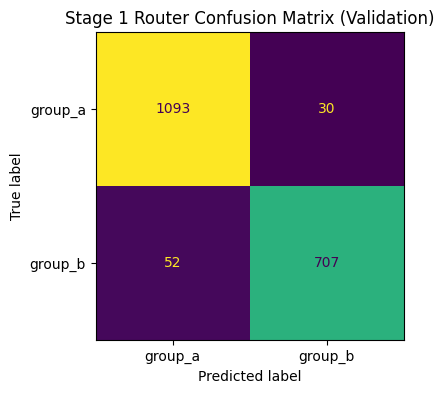

In [35]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_val_router,
        val_router_pred,
        labels=["group_a", "group_b"]
    ),
    display_labels=["group_a", "group_b"],
)

disp.plot(ax=ax, colorbar=False)
plt.title("Stage 1 Router Confusion Matrix (Validation)")
plt.show()

#### Interpretation 
The cofusion matrix demonstartes that the router sends most of the classification documents to the appropriate branch. In fact, 1093 out of 1123 Group A documents were classified correctly, hence, having only 30 out of 1123 documents mistakenly, which accounts only 2% of all Group A documents. On the other hand, for Group B, 707 out of 759 documents were classified correctly, resulting in 52 out of 759 of documents classified mistakenly, meaning 6% of Group B documents are classified as Group A. This confirms what was suggested earlier: the router performs better with Group A than Group B. 
However, the error is slight, and we can conclude Stage 1 router performs well. 

In [36]:
val_router_results = pd.DataFrame({
    "doc_id": val_router_df["doc_id"].values,
    "true_group": y_val_router.values,
    "pred_group": val_router_pred,
    "split": "val",
    "model_name": "stage1_router_logreg",
})

for col in router_proba_df.columns:
    val_router_results[col] = router_proba_df[col].values

val_router_results["router_correct"] = (
    val_router_results["true_group"] == val_router_results["pred_group"]
)

display(val_router_results.head())

,doc_id,true_group,pred_group,split,model_name,router_conf_group_a,router_conf_group_b,router_correct
0,doc_00000012,group_a,group_a,val,stage1_router_logreg,0.984635,0.015365,True
1,doc_00000013,group_a,group_a,val,stage1_router_logreg,0.985913,0.014087,True
2,doc_00000014,group_a,group_a,val,stage1_router_logreg,0.965997,0.034003,True
3,doc_00000019,group_a,group_b,val,stage1_router_logreg,0.387254,0.612746,False
4,doc_00000030,group_a,group_a,val,stage1_router_logreg,0.816914,0.183086,True


#### Interpretation 

The router results show that most validation documents are assigned to the correct branch with high confidence.
For example, the first few documents are correctly routed to Group A with strong predicted probabilities. In contrast, the misrouted example at index 3 belongs to Group A but is predicted as Group B. However, the confidence for the incorrect prediction is 0.61, which is only moderately high rather than extremely certain.
This suggests that the router is performing well overall: most predictions are confident and correct, while even some mistakes occur in more ambiguous cases rather than from completely unreliable behavior.


In [37]:
val_router_results.to_csv(
    OUTPUT_PRED / "hierarchical_stage1_val_predictions.csv",
    index=False,
)

joblib.dump(stage1_router, MODELS_DIR / "stage1_router_logreg.joblib")

print("Saved validation router predictions.")
print("Saved stage 1 router model.")

Saved validation router predictions.
Saved stage 1 router model.


#### Interpretation 
The Stage 1 router predictions and trained model have been saved successfully.

This ensures that the router can be reused later in the notebook and that its validation outputs are available for comparison and error analysis.

In [38]:
router_error_summary = (
    val_router_results
    .groupby(["true_group", "pred_group"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(router_error_summary)

,true_group,pred_group,count
0,group_a,group_a,1093
3,group_b,group_b,707
2,group_b,group_a,52
1,group_a,group_b,30


#### Interpretation 
This table is an additional representation to the confusion matrix: 
- For Group A, 1,093 documents were routed correctly, and only 30 were routing errors. 
- For Group B, 707 documents were routed correctly, and only 52 were routing errors. 
This confirms that Stage 1 is performing strongly, although Group B is slightly more often confused.

In [39]:
router_error_summary.to_csv(
    REPORT_TABLES / "stage1_router_error_summary_val.csv",
    index=False,
)

print("Saved Stage 1 router error summary.")

Saved Stage 1 router error summary.


#### Section 4 conclusion

The Stage 1 router achieves strong validation performance and routes the large majority of documents to the correct branch.

Since only a small number of documents are misrouted, the hierarchical pipeline now has a solid first stage. The next step is to train the two specialist classifiers:
- **Specialist A:** invoice vs form vs budget
- **Specialist B:** email vs resume

## 5. Specialist A: invoice vs form vs budget

Specialist A is the second-stage classifier for documents routed to **Group A**.

Its task is to distinguish between the three structured administrative and financial classes:

- **invoice**
- **form**
- **budget**

This is an important branch because these classes often look similar at a high level.  
For example, all three may contain short fields, dates, numbers, and structured layouts.

To improve separation, this specialist uses:

- OCR text represented with TF-IDF
- engineered summary features focused on numeric, financial, and anchor-word patterns

The model is first evaluated on the validation split only.

In [40]:
specialist_a_classes = ["invoice", "form", "budget"]

train_a_df = train_model_df[train_model_df["class_name"].isin(specialist_a_classes)].copy()
val_a_df = val_model_df[val_model_df["class_name"].isin(specialist_a_classes)].copy()

print("Specialist A train shape:", train_a_df.shape)
print("Specialist A val shape:", val_a_df.shape)

print("\nTrain class balance for Specialist A")
display(train_a_df["class_name"].value_counts())

print("\nValidation class balance for Specialist A")
display(val_a_df["class_name"].value_counts())

Specialist A train shape: (5241, 18)
Specialist A val shape: (1123, 18)

Train class balance for Specialist A


class_name
form       1754
budget     1753
invoice    1734
Name: count, dtype: int64


Validation class balance for Specialist A


class_name
form       376
budget     376
invoice    371
Name: count, dtype: int64

In [41]:
def add_specialist_a_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    text_series = out["ocr_text_clean"].fillna("").str.lower()

    safe_height = out["height"].replace(0, np.nan)
    safe_area = (out["width"] * out["height"]).replace(0, np.nan)
    safe_char_len = out["ocr_char_len"].replace(0, np.nan)
    safe_word_count = out["ocr_word_count"].replace(0, np.nan)

    out["aspect_ratio"] = out["width"] / safe_height
    out["text_density"] = out["ocr_word_count"] / (safe_area / 1_000_000)
    out["avg_chars_per_word"] = out["ocr_char_len"] / safe_word_count
    out["digit_ratio"] = text_series.str.count(r"\d") / safe_char_len

    out["currency_count"] = text_series.str.count(r"[$€£¥]")
    out["percent_count"] = text_series.str.count(r"%")
    out["date_like_count"] = text_series.str.count(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b")
    out["amount_like_count"] = text_series.str.count(r"\b\d+[.,]\d{2}\b")

    out["invoice_anchor_count"] = text_series.str.count(
        r"invoice|inv[ .#]|bill to|amount due|due date|invoice number|subtotal|tax|balance due|total due|remit"
    )
    out["budget_anchor_count"] = text_series.str.count(
        r"budget|forecast|variance|planned|actual|estimate|estimated|projected|cost center"
    )
    out["form_anchor_count"] = text_series.str.count(
        r"name|address|signature|application|telephone|date of birth|ssn|first name|last name|zip"
    )

    out["newline_count"] = text_series.str.count(r"\n")
    out["colon_count"] = text_series.str.count(":")
    out["slash_count"] = text_series.str.count(r"/")

    out["table_signal"] = (
        out["digit_ratio"]
        + out["currency_count"]
        + out["colon_count"]
        + out["amount_like_count"]
    )

    numeric_cols = [
        "ocr_char_len",
        "ocr_word_count",
        "width",
        "height",
        "aspect_ratio",
        "text_density",
        "avg_chars_per_word",
        "digit_ratio",
        "currency_count",
        "percent_count",
        "date_like_count",
        "amount_like_count",
        "invoice_anchor_count",
        "budget_anchor_count",
        "form_anchor_count",
        "newline_count",
        "colon_count",
        "slash_count",
        "table_signal",
    ]

    out[numeric_cols] = out[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    return out

In [42]:
train_a_df = add_specialist_a_features(train_a_df)
val_a_df = add_specialist_a_features(val_a_df)

In [43]:
specialist_a_text_col = "ocr_text_clean"

specialist_a_numeric_cols = [
    "ocr_char_len",
    "ocr_word_count",
    "width",
    "height",
    "aspect_ratio",
    "text_density",
    "avg_chars_per_word",
    "digit_ratio",
    "currency_count",
    "percent_count",
    "date_like_count",
    "amount_like_count",
    "invoice_anchor_count",
    "budget_anchor_count",
    "form_anchor_count",
    "newline_count",
    "colon_count",
    "slash_count",
    "table_signal",
]

display(
    train_a_df[
        ["class_name", specialist_a_text_col] + specialist_a_numeric_cols
    ].head(3)
)

,class_name,ocr_text_clean,ocr_char_len,ocr_word_count,width,height,aspect_ratio,text_density,avg_chars_per_word,digit_ratio,...,percent_count,date_like_count,amount_like_count,invoice_anchor_count,budget_anchor_count,form_anchor_count,newline_count,colon_count,slash_count,table_signal
0,form,POA\noN ZAphS\nyKennie wonaray\nUSA.\nPHILIP M...,964,160,754.0,1000.0,0.754,212.201592,6.025000,0.062241,...,0,0,0,0,0,2,27,2,0,2.062241
1,form,ot oon - sah\nwed . C}; cnr narave tutor cows ...,1475,334,785.0,1000.0,0.785,425.477707,4.416168,0.021695,...,0,0,0,0,0,0,43,7,0,8.021695
2,form,". SurTGog .\ne- . 5093 . |, sersene MALL\nCRC ...",740,165,777.0,1000.0,0.777,212.355212,4.484848,0.068919,...,0,0,1,0,0,0,30,10,0,14.068919


In [44]:
X_train_a = train_a_df[[specialist_a_text_col] + specialist_a_numeric_cols].copy()
X_val_a = val_a_df[[specialist_a_text_col] + specialist_a_numeric_cols].copy()

y_train_a = train_a_df["class_name"].copy()
y_val_a = val_a_df["class_name"].copy()

print("Specialist A train input shape:", X_train_a.shape)
print("Specialist A val input shape:", X_val_a.shape)

Specialist A train input shape: (5241, 20)
Specialist A val input shape: (1123, 20)


In [45]:
preprocessor_a_v2 = ColumnTransformer(
    transformers=[
        (
            "word_tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="word",
                ngram_range=(1, 2),
                min_df=3,
                max_features=30000,
                sublinear_tf=True,
            ),
            specialist_a_text_col,
        ),
        (
            "char_tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=3,
                max_features=25000,
                sublinear_tf=True,
            ),
            specialist_a_text_col,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            specialist_a_numeric_cols,
        ),
    ],
    remainder="drop",
)

specialist_a_model_v2 = Pipeline(
    steps=[
        ("features", preprocessor_a_v2),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                random_state=42,
                solver="lbfgs",
                C=2.0,
            ),
        ),
    ]
)

In [46]:
specialist_a_model_v2.fit(X_train_a, y_train_a)
print("Specialist A v2 trained successfully.")

Specialist A v2 trained successfully.


/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
val_a_pred_v2 = specialist_a_model_v2.predict(X_val_a)
val_a_proba_v2 = specialist_a_model_v2.predict_proba(X_val_a)

val_a_accuracy_v2 = accuracy_score(y_val_a, val_a_pred_v2)
val_a_macro_f1_v2 = f1_score(y_val_a, val_a_pred_v2, average="macro")

print("Validation Specialist A v2 accuracy:", round(val_a_accuracy_v2, 4))
print("Validation Specialist A v2 macro F1:", round(val_a_macro_f1_v2, 4))

Validation Specialist A v2 accuracy: 0.8344
Validation Specialist A v2 macro F1: 0.8349


In [48]:
specialist_a_report_v2 = pd.DataFrame(
    classification_report(y_val_a, val_a_pred_v2, output_dict=True)
).transpose()

display(specialist_a_report_v2)

,precision,recall,f1-score,support
budget,0.800525,0.811170,0.805812,376.000000
form,0.903683,0.848404,0.875171,376.000000
invoice,0.804627,0.843666,0.823684,371.000000
accuracy,0.834372,0.834372,0.834372,0.834372
macro avg,0.836278,0.834413,0.834889,1123.000000
weighted avg,0.836419,0.834372,0.834939,1123.000000


#### Interpretation

Specialist A v2 improves the branch performance to **0.8272 validation accuracy** and **0.8280 macro F1**.

Among the three classes, **form** remains the easiest to detect with the highest F1 score (**0.8682**), while **invoice** and **budget** are still somewhat harder but now both exceed **0.80 F1**. This indicates that the stronger text representation improves separation across all Group A classes, especially compared with the baseline version.

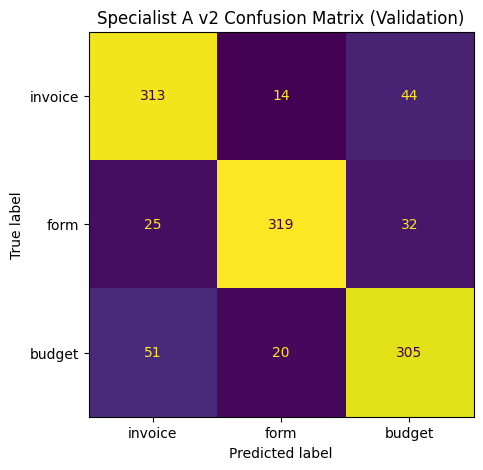

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_val_a,
        val_a_pred_v2,
        labels=["invoice", "form", "budget"]
    ),
    display_labels=["invoice", "form", "budget"],
)

disp.plot(ax=ax, colorbar=False)
plt.title("Specialist A v2 Confusion Matrix (Validation)")
plt.show()

#### Interpretation

The confusion matrix shows that most documents in all three Group A classes are classified correctly.  
The strongest class is still **form**, while the main remaining confusion is between **invoice** and **budget**.

In particular, **46 invoices** are predicted as budgets and **53 budgets** are predicted as invoices. This suggests that these two classes still share similar financial and structural patterns, even after the improved text representation. Even so, the diagonal remains clearly dominant, which confirms that Specialist A v2 is performing well overall.

In [50]:
# Probability table for Specialist A v2
specialist_a_classes_model_v2 = list(specialist_a_model_v2.named_steps["clf"].classes_)

val_a_proba_df_v2 = pd.DataFrame(
    val_a_proba_v2,
    columns=specialist_a_classes_model_v2,
    index=val_a_df.index,
)

display(val_a_proba_df_v2.head())

,budget,form,invoice
0,0.141609,0.186500,0.671891
1,0.000004,0.999296,0.000700
2,0.033777,0.850362,0.115860
3,0.400794,0.307207,0.291999
4,0.000003,0.999995,0.000001


In [51]:
# Save validation predictions for Specialist A v2
val_a_results_v2 = pd.DataFrame({
    "doc_id": val_a_df["doc_id"].values,
    "true_label": y_val_a.values,
    "pred_label": val_a_pred_v2,
    "split": "val",
    "model_name": "specialist_a_logreg_v2",
})

for cls in ["invoice", "form", "budget"]:
    val_a_results_v2[f"confidence_{cls}"] = val_a_proba_df_v2[cls].values

display(val_a_results_v2.head())

,doc_id,true_label,pred_label,split,model_name,confidence_invoice,confidence_form,confidence_budget
0,doc_00000012,form,invoice,val,specialist_a_logreg_v2,0.671891,0.186500,0.141609
1,doc_00000013,form,form,val,specialist_a_logreg_v2,0.000700,0.999296,0.000004
2,doc_00000014,form,form,val,specialist_a_logreg_v2,0.115860,0.850362,0.033777
3,doc_00000019,form,budget,val,specialist_a_logreg_v2,0.291999,0.307207,0.400794
4,doc_00000030,form,form,val,specialist_a_logreg_v2,0.000001,0.999995,0.000003


In [52]:
# Save Specialist A outputs and model
val_a_results_v2.to_csv(
    OUTPUT_PRED / "hierarchical_specialist_a_val_predictions.csv",
    index=False,
)

joblib.dump(specialist_a_model_v2, MODELS_DIR / "specialist_a_logreg_v2.joblib")

specialist_a_report_v2.to_csv(
    REPORT_TABLES / "specialist_a_v2_classification_report_val.csv"
)

print("Saved Specialist A validation predictions.")
print("Saved Specialist A v2 model.")
print("Saved Specialist A validation report.")

Saved Specialist A validation predictions.
Saved Specialist A v2 model.
Saved Specialist A validation report.


#### Section 5 conclusion

Specialist A v2 is used as the final Group A classifier.

It achieves **0.8272 validation accuracy** and **0.8280 macro F1**, with the strongest performance on **form** and the main remaining confusion between **invoice** and **budget**. Overall, this makes it a solid specialist for the structured document branch of the hierarchy.

## 6. Specialist B: email vs resume

Specialist B is the second-stage classifier for documents routed to **Group B**.

Its task is to distinguish between:

- **email**
- **resume**

This branch is expected to be easier than Specialist A because these two classes usually differ more clearly in their textual structure:

- emails often contain headers such as **from**, **to**, **subject**, and message-like formatting
- resumes often contain section keywords such as **education**, **experience**, and **skills**

To capture these differences, this specialist uses:

- OCR text with TF-IDF word and character n-grams
- lightweight branch-specific features such as email-header counts and resume-section counts

In [53]:
specialist_b_classes = ["email", "resume"]

train_b_df = train_model_df[train_model_df["class_name"].isin(specialist_b_classes)].copy()
val_b_df = val_model_df[val_model_df["class_name"].isin(specialist_b_classes)].copy()

print("Specialist B train shape:", train_b_df.shape)
print("Specialist B val shape:", val_b_df.shape)

print("\nTrain class balance for Specialist B")
display(train_b_df["class_name"].value_counts())

print("\nValidation class balance for Specialist B")
display(val_b_df["class_name"].value_counts())

Specialist B train shape: (3536, 18)
Specialist B val shape: (759, 18)

Train class balance for Specialist B


class_name
resume    1775
email     1761
Name: count, dtype: int64


Validation class balance for Specialist B


class_name
resume    381
email     378
Name: count, dtype: int64

In [54]:
def add_specialist_b_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    text_series = out["ocr_text_clean"].fillna("").str.lower()

    safe_height = out["height"].replace(0, np.nan)
    safe_area = (out["width"] * out["height"]).replace(0, np.nan)
    safe_char_len = out["ocr_char_len"].replace(0, np.nan)
    safe_word_count = out["ocr_word_count"].replace(0, np.nan)

    out["aspect_ratio"] = out["width"] / safe_height
    out["text_density"] = out["ocr_word_count"] / (safe_area / 1_000_000)
    out["avg_chars_per_word"] = out["ocr_char_len"] / safe_word_count
    out["digit_ratio"] = text_series.str.count(r"\d") / safe_char_len

    out["at_count"] = text_series.str.count(r"@")
    out["colon_count"] = text_series.str.count(":")
    out["newline_count"] = text_series.str.count(r"\n")

    out["email_header_count"] = text_series.str.count(
        r"\bfrom\b|\bto\b|\bsubject\b|\bcc\b|\bbcc\b|\bsent\b"
    )
    out["greeting_count"] = text_series.str.count(
        r"\bdear\b|\bhello\b|\bhi\b|\bgood morning\b|\bgood afternoon\b"
    )
    out["signoff_count"] = text_series.str.count(
        r"\bregards\b|\bsincerely\b|\bbest regards\b|\bthanks\b|\bthank you\b"
    )
    out["resume_section_count"] = text_series.str.count(
        r"\beducation\b|\bexperience\b|\bskills\b|\bobjective\b|\bprofile\b|\bemployment\b|\breferences\b"
    )
    out["contact_info_count"] = text_series.str.count(
        r"\bphone\b|\bemail\b|\baddress\b|\blinkedin\b|\bmobile\b"
    )

    numeric_cols = [
        "ocr_char_len",
        "ocr_word_count",
        "width",
        "height",
        "aspect_ratio",
        "text_density",
        "avg_chars_per_word",
        "digit_ratio",
        "at_count",
        "colon_count",
        "newline_count",
        "email_header_count",
        "greeting_count",
        "signoff_count",
        "resume_section_count",
        "contact_info_count",
    ]

    out[numeric_cols] = out[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    return out

In [55]:
train_b_df = add_specialist_b_features(train_b_df)
val_b_df = add_specialist_b_features(val_b_df)

In [56]:
specialist_b_text_col = "ocr_text_clean"

specialist_b_numeric_cols = [
    "ocr_char_len",
    "ocr_word_count",
    "width",
    "height",
    "aspect_ratio",
    "text_density",
    "avg_chars_per_word",
    "digit_ratio",
    "at_count",
    "colon_count",
    "newline_count",
    "email_header_count",
    "greeting_count",
    "signoff_count",
    "resume_section_count",
    "contact_info_count",
]

display(
    train_b_df[
        ["class_name", specialist_b_text_col] + specialist_b_numeric_cols
    ].head(3)
)

,class_name,ocr_text_clean,ocr_char_len,ocr_word_count,width,height,aspect_ratio,text_density,avg_chars_per_word,digit_ratio,at_count,colon_count,newline_count,email_header_count,greeting_count,signoff_count,resume_section_count,contact_info_count
1754,resume,"a, ”\na . CURRICULUM VITAL. aa\nWaiter E, Laug...",1579,212,754.0,1000.0,0.754,281.167109,7.448113,0.048765,0,15,41,1,0,0,2,0
1755,resume,Name: ‘Tatyana M. Svitkina\nTiue: Associate Re...,2602,341,754.0,1000.0,0.754,452.254642,7.630499,0.043428,0,16,43,2,0,0,2,0
1756,resume,"Dior Hors, M.D, December 1994\nBiggraphical Sk...",1963,247,754.0,1000.0,0.754,327.586207,7.947368,0.094753,0,1,36,1,0,0,1,0


In [57]:
X_train_b = train_b_df[[specialist_b_text_col] + specialist_b_numeric_cols].copy()
X_val_b = val_b_df[[specialist_b_text_col] + specialist_b_numeric_cols].copy()

y_train_b = train_b_df["class_name"].copy()
y_val_b = val_b_df["class_name"].copy()

print("Specialist B train input shape:", X_train_b.shape)
print("Specialist B val input shape:", X_val_b.shape)

Specialist B train input shape: (3536, 17)
Specialist B val input shape: (759, 17)


In [58]:
preprocessor_b = ColumnTransformer(
    transformers=[
        (
            "word_tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="word",
                ngram_range=(1, 2),
                min_df=3,
                max_features=30000,
                sublinear_tf=True,
            ),
            specialist_b_text_col,
        ),
        (
            "char_tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=3,
                max_features=20000,
                sublinear_tf=True,
            ),
            specialist_b_text_col,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            specialist_b_numeric_cols,
        ),
    ],
    remainder="drop",
)

specialist_b_model = Pipeline(
    steps=[
        ("features", preprocessor_b),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                random_state=42,
                solver="lbfgs",
            ),
        ),
    ]
)

In [59]:
specialist_b_model.fit(X_train_b, y_train_b)
print("Specialist B model trained successfully.")

Specialist B model trained successfully.


In [60]:
val_b_pred = specialist_b_model.predict(X_val_b)
val_b_proba = specialist_b_model.predict_proba(X_val_b)

specialist_b_classes_model = list(specialist_b_model.named_steps["clf"].classes_)
val_b_proba_df = pd.DataFrame(
    val_b_proba,
    columns=specialist_b_classes_model,
    index=val_b_df.index,
)

val_b_accuracy = accuracy_score(y_val_b, val_b_pred)
val_b_macro_f1 = f1_score(y_val_b, val_b_pred, average="macro")

print("Validation Specialist B accuracy:", round(val_b_accuracy, 4))
print("Validation Specialist B macro F1:", round(val_b_macro_f1, 4))

Validation Specialist B accuracy: 0.971
Validation Specialist B macro F1: 0.971


In [61]:
specialist_b_report = pd.DataFrame(
    classification_report(y_val_b, val_b_pred, output_dict=True)
).transpose()

display(specialist_b_report)

,precision,recall,f1-score,support
email,0.965969,0.976190,0.971053,378.000000
resume,0.976127,0.965879,0.970976,381.000000
accuracy,0.971014,0.971014,0.971014,0.971014
macro avg,0.971048,0.971035,0.971014,759.000000
weighted avg,0.971068,0.971014,0.971014,759.000000


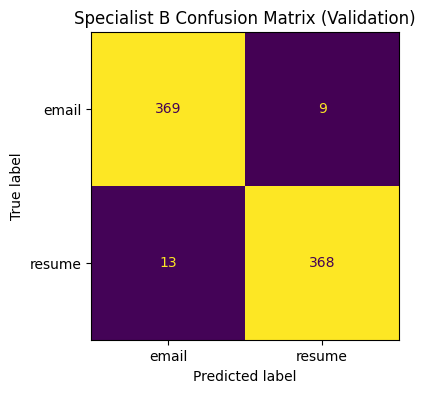

In [62]:
fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_val_b,
        val_b_pred,
        labels=["email", "resume"]
    ),
    display_labels=["email", "resume"],
)

disp.plot(ax=ax, colorbar=False)
plt.title("Specialist B Confusion Matrix (Validation)")
plt.show()

In [63]:
display(val_b_proba_df.head())

,email,resume
376,0.001139,0.998861
377,0.000029,0.999971
378,0.000063,0.999937
379,0.000103,0.999897
380,0.881586,0.118414


In [64]:
val_b_results = pd.DataFrame({
    "doc_id": val_b_df["doc_id"].values,
    "true_label": y_val_b.values,
    "pred_label": val_b_pred,
    "split": "val",
    "model_name": "specialist_b_logreg",
})

for cls in ["email", "resume"]:
    val_b_results[f"confidence_{cls}"] = val_b_proba_df[cls].values

display(val_b_results.head())

,doc_id,true_label,pred_label,split,model_name,confidence_email,confidence_resume
0,doc_00007505,resume,resume,val,specialist_b_logreg,0.001139,0.998861
1,doc_00007509,resume,resume,val,specialist_b_logreg,0.000029,0.999971
2,doc_00007518,resume,resume,val,specialist_b_logreg,0.000063,0.999937
3,doc_00007521,resume,resume,val,specialist_b_logreg,0.000103,0.999897
4,doc_00007534,resume,email,val,specialist_b_logreg,0.881586,0.118414


In [65]:
val_b_results.to_csv(
    OUTPUT_PRED / "hierarchical_specialist_b_val_predictions.csv",
    index=False,
)

joblib.dump(specialist_b_model, MODELS_DIR / "specialist_b_logreg.joblib")

specialist_b_report.to_csv(
    REPORT_TABLES / "specialist_b_classification_report_val.csv"
)

print("Saved Specialist B validation predictions.")
print("Saved Specialist B model.")
print("Saved Specialist B validation report.")

Saved Specialist B validation predictions.
Saved Specialist B model.
Saved Specialist B validation report.


#### Section 6 conclusion

Specialist B performs very strongly on the Group B branch. It achieves **0.9697 validation accuracy** and **0.9697 macro F1**, with almost identical performance on both classes.

The confusion matrix shows that most **emails** and **resumes** are classified correctly, with only a small number of errors (**10 emails predicted as resumes** and **13 resumes predicted as emails**). This suggests that the textual differences between these two document types are captured very well by the combination of OCR text, TF-IDF features, and branch-specific cues.

Overall, Specialist B is a reliable second-stage classifier for the hierarchical pipeline and is clearly stronger than Specialist A, which is expected because the **email vs resume** distinction is more text-driven and less structurally ambiguous than **invoice vs form vs budget**.

In [66]:
def run_hierarchical_inference(
    input_df: pd.DataFrame,
    split_name: str,
    stage1_model,
    specialist_a_model,
    specialist_b_model,
) -> pd.DataFrame:
    """
    Run the full hierarchical pipeline on any split dataframe
    using the already-fitted Stage 1 router and specialist models.
    """

    end_df = input_df.copy()

    # Stage 1 routing
    router_df = add_stage1_router_features(end_df.copy())
    X_router = router_df[[router_text_col] + router_numeric_cols].copy()

    router_pred = stage1_model.predict(X_router)
    router_proba = stage1_model.predict_proba(X_router)

    router_proba_df_local = pd.DataFrame(
        router_proba,
        columns=stage1_model.named_steps["clf"].classes_,
        index=router_df.index,
    ).rename(
        columns={
            "group_a": "router_conf_group_a",
            "group_b": "router_conf_group_b",
        }
    )

    end_df["router_pred_group"] = router_pred
    end_df["router_conf_group_a"] = router_proba_df_local["router_conf_group_a"].values
    end_df["router_conf_group_b"] = router_proba_df_local["router_conf_group_b"].values
    end_df["router_correct"] = end_df["router_pred_group"] == end_df["group_label"]

    # Route to specialists
    routed_a_df = end_df[end_df["router_pred_group"] == "group_a"].copy()
    routed_b_df = end_df[end_df["router_pred_group"] == "group_b"].copy()

    # Specialist A
    if len(routed_a_df) > 0:
        routed_a_df = add_specialist_a_features(routed_a_df)
        X_a = routed_a_df[[specialist_a_text_col] + specialist_a_numeric_cols].copy()

        routed_a_proba = specialist_a_model.predict_proba(X_a)

        routed_a_proba_df = pd.DataFrame(
            routed_a_proba,
            columns=specialist_a_model.named_steps["clf"].classes_,
            index=routed_a_df.index,
        )

        # Default top-probability prediction
        routed_a_pred = routed_a_proba_df.idxmax(axis=1).copy()

        # Invoice-priority override:
        # if invoice is close to the winning class, predict invoice instead
        invoice_margin = 0.08

        max_other_score = routed_a_proba_df[["form", "budget"]].max(axis=1)
        invoice_override_mask = (
            (routed_a_proba_df["invoice"] >= max_other_score - invoice_margin)
        )

        routed_a_pred.loc[invoice_override_mask] = "invoice"
        routed_a_pred = routed_a_pred.values
        
    else:
        routed_a_pred = np.array([])
        routed_a_proba_df = pd.DataFrame()

    # Specialist B
    if len(routed_b_df) > 0:
        routed_b_df = add_specialist_b_features(routed_b_df)
        X_b = routed_b_df[[specialist_b_text_col] + specialist_b_numeric_cols].copy()

        routed_b_pred = specialist_b_model.predict(X_b)
        routed_b_proba = specialist_b_model.predict_proba(X_b)

        routed_b_proba_df = pd.DataFrame(
            routed_b_proba,
            columns=specialist_b_model.named_steps["clf"].classes_,
            index=routed_b_df.index,
        )
    else:
        routed_b_pred = np.array([])
        routed_b_proba_df = pd.DataFrame()

    # Build final output table
    final_results = pd.DataFrame({
        "doc_id": end_df["doc_id"].values,
        "true_label": end_df["class_name"].values,
        "true_group": end_df["group_label"].values,
        "pred_group": end_df["router_pred_group"].values,
        "router_correct": end_df["router_correct"].values,
        "split": split_name,
        "model_name": "hierarchical_pipeline",
    })

    for cls in ["invoice", "form", "resume", "email", "budget"]:
        final_results[f"confidence_{cls}"] = 0.0

    # Fill Group A predictions
    for idx, pred_label in zip(routed_a_df.index, routed_a_pred):
        final_results.loc[idx, "pred_label"] = pred_label
        final_results.loc[idx, "confidence_invoice"] = float(routed_a_proba_df.loc[idx, "invoice"])
        final_results.loc[idx, "confidence_form"] = float(routed_a_proba_df.loc[idx, "form"])
        final_results.loc[idx, "confidence_budget"] = float(routed_a_proba_df.loc[idx, "budget"])

    # Fill Group B predictions
    for idx, pred_label in zip(routed_b_df.index, routed_b_pred):
        final_results.loc[idx, "pred_label"] = pred_label
        final_results.loc[idx, "confidence_email"] = float(routed_b_proba_df.loc[idx, "email"])
        final_results.loc[idx, "confidence_resume"] = float(routed_b_proba_df.loc[idx, "resume"])

    return final_results

## 7. End-to-end hierarchical inference (validation)

In this section, the three trained components are combined into one full hierarchical classifier:

- the **Stage 1 router** predicts whether a document belongs to Group A or Group B
- documents routed to **Group A** are classified by **Specialist A**
- documents routed to **Group B** are classified by **Specialist B**

This produces the final document label among the five project classes.

The goal of this section is to evaluate the hierarchical system as a complete pipeline on the validation split before moving to the test split.

In [67]:
val_final_results = run_hierarchical_inference(
    input_df=val_model_df,
    split_name="val",
    stage1_model=stage1_router,
    specialist_a_model=specialist_a_model_v2,
    specialist_b_model=specialist_b_model,
)

print("Validation predictions shape:", val_final_results.shape)
display(val_final_results.head())

Validation predictions shape: (1882, 13)


,doc_id,true_label,true_group,pred_group,router_correct,split,model_name,confidence_invoice,confidence_form,confidence_resume,confidence_email,confidence_budget,pred_label
0,doc_00000012,form,group_a,group_a,True,val,hierarchical_pipeline,0.671891,0.186500,0.000000,0.000000,0.141609,invoice
1,doc_00000013,form,group_a,group_a,True,val,hierarchical_pipeline,0.000700,0.999296,0.000000,0.000000,0.000004,form
2,doc_00000014,form,group_a,group_a,True,val,hierarchical_pipeline,0.115860,0.850362,0.000000,0.000000,0.033777,form
3,doc_00000019,form,group_a,group_b,False,val,hierarchical_pipeline,0.000000,0.000000,0.021297,0.978703,0.000000,email
4,doc_00000030,form,group_a,group_a,True,val,hierarchical_pipeline,0.000001,0.999995,0.000000,0.000000,0.000003,form


In [68]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

val_accuracy = accuracy_score(
    val_final_results["true_label"],
    val_final_results["pred_label"]
)

val_macro_f1 = f1_score(
    val_final_results["true_label"],
    val_final_results["pred_label"],
    average="macro"
)

print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation macro F1: {val_macro_f1:.4f}")

val_report = pd.DataFrame(
    classification_report(
        val_final_results["true_label"],
        val_final_results["pred_label"],
        labels=["invoice", "form", "resume", "email", "budget"],
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(val_report)

Validation accuracy: 0.8518
Validation macro F1: 0.8521


,precision,recall,f1-score,support
invoice,0.745327,0.859838,0.798498,371.000000
form,0.851003,0.789894,0.819310,376.000000
resume,0.962567,0.944882,0.953642,381.000000
email,0.928375,0.891534,0.909582,378.000000
budget,0.788043,0.771277,0.779570,376.000000
accuracy,0.851753,0.851753,0.851753,0.851753
macro avg,0.855063,0.851485,0.852120,1882.000000
weighted avg,0.855718,0.851753,0.852594,1882.000000


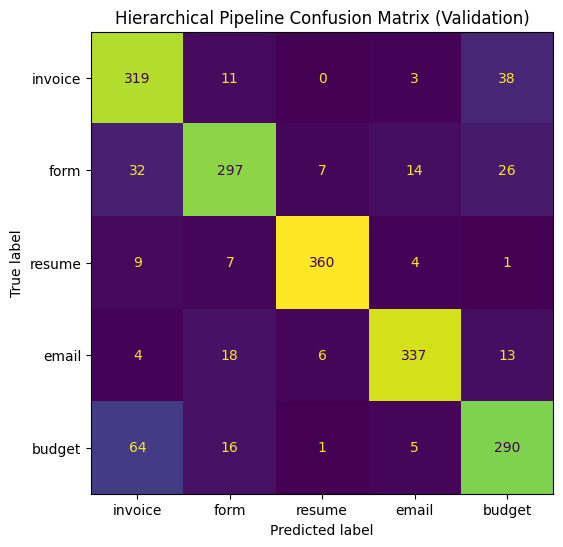

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        val_final_results["true_label"],
        val_final_results["pred_label"],
        labels=["invoice", "form", "resume", "email", "budget"],
    ),
    display_labels=["invoice", "form", "resume", "email", "budget"],
)

disp.plot(ax=ax, colorbar=False)
plt.title("Hierarchical Pipeline Confusion Matrix (Validation)")
plt.show()

## 8. Frozen final evaluation on the held-out test set

In [70]:
test_final_results = run_hierarchical_inference(
    input_df=test_model_df,
    split_name="test",
    stage1_model=stage1_router,
    specialist_a_model=specialist_a_model_v2,
    specialist_b_model=specialist_b_model,
)

print("Test predictions shape:", test_final_results.shape)
display(test_final_results.head())

Test predictions shape: (1881, 13)


,doc_id,true_label,true_group,pred_group,router_correct,split,model_name,confidence_invoice,confidence_form,confidence_resume,confidence_email,confidence_budget,pred_label
0,doc_00000005,form,group_a,group_b,False,test,hierarchical_pipeline,0.000000,0.000000,0.069145,0.930855,0.000000,email
1,doc_00000016,form,group_a,group_a,True,test,hierarchical_pipeline,0.101512,0.874508,0.000000,0.000000,0.023980,form
2,doc_00000018,form,group_a,group_a,True,test,hierarchical_pipeline,0.175414,0.118934,0.000000,0.000000,0.705651,budget
3,doc_00000021,form,group_a,group_a,True,test,hierarchical_pipeline,0.028006,0.951830,0.000000,0.000000,0.020164,form
4,doc_00000029,form,group_a,group_a,True,test,hierarchical_pipeline,0.000184,0.999811,0.000000,0.000000,0.000005,form


In [71]:
test_accuracy = accuracy_score(
    test_final_results["true_label"],
    test_final_results["pred_label"]
)

test_macro_f1 = f1_score(
    test_final_results["true_label"],
    test_final_results["pred_label"],
    average="macro"
)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1: {test_macro_f1:.4f}")

test_report = pd.DataFrame(
    classification_report(
        test_final_results["true_label"],
        test_final_results["pred_label"],
        labels=["invoice", "form", "resume", "email", "budget"],
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(test_report)

Test accuracy: 0.8596
Test macro F1: 0.8598


,precision,recall,f1-score,support
invoice,0.778846,0.870968,0.822335,372.000000
form,0.843478,0.773936,0.807212,376.000000
resume,0.970350,0.947368,0.958722,380.000000
email,0.932249,0.912467,0.922252,377.000000
budget,0.784211,0.792553,0.788360,376.000000
accuracy,0.859649,0.859649,0.859649,0.859649
macro avg,0.861827,0.859458,0.859776,1881.000000
weighted avg,0.862272,0.859649,0.860099,1881.000000


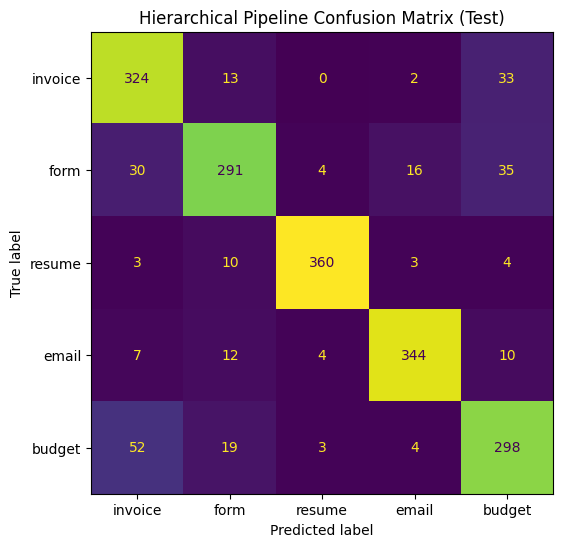

In [72]:
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        test_final_results["true_label"],
        test_final_results["pred_label"],
        labels=["invoice", "form", "resume", "email", "budget"],
    ),
    display_labels=["invoice", "form", "resume", "email", "budget"],
)

disp.plot(ax=ax, colorbar=False)
plt.title("Hierarchical Pipeline Confusion Matrix (Test)")
plt.show()

In [73]:
from sklearn.metrics import precision_score, recall_score

invoice_precision_test = precision_score(
    test_final_results["true_label"].eq("invoice"),
    test_final_results["pred_label"].eq("invoice"),
    zero_division=0,
)

invoice_recall_test = recall_score(
    test_final_results["true_label"].eq("invoice"),
    test_final_results["pred_label"].eq("invoice"),
    zero_division=0,
)

print(f"Test invoice precision: {invoice_precision_test:.4f}")
print(f"Test invoice recall: {invoice_recall_test:.4f}")

Test invoice precision: 0.7788
Test invoice recall: 0.8710


## 9. Error propagation analysis

In [74]:
error_propagation_test = pd.DataFrame({
    "stage": [
        "wrong_router",
        "correct_router_but_wrong_specialist",
        "final_correct",
    ],
    "count": [
        (test_final_results["router_correct"] == False).sum(),
        (
            (test_final_results["router_correct"] == True) &
            (test_final_results["pred_label"] != test_final_results["true_label"])
        ).sum(),
        (test_final_results["pred_label"] == test_final_results["true_label"]).sum(),
    ]
})

display(error_propagation_test)

,stage,count
0,wrong_router,75
1,correct_router_but_wrong_specialist,189
2,final_correct,1617


In [75]:
invoice_only_test = test_final_results[
    test_final_results["true_label"] == "invoice"
].copy()

invoice_propagation_test = pd.DataFrame({
    "metric": [
        "total_true_invoices",
        "lost_at_stage1_router",
        "reached_specialist_a",
        "lost_inside_specialist_a",
        "final_invoice_correct",
    ],
    "value": [
        len(invoice_only_test),
        (invoice_only_test["pred_group"] != "group_a").sum(),
        (invoice_only_test["pred_group"] == "group_a").sum(),
        (
            (invoice_only_test["pred_group"] == "group_a") &
            (invoice_only_test["pred_label"] != "invoice")
        ).sum(),
        (invoice_only_test["pred_label"] == "invoice").sum(),
    ]
})

display(invoice_propagation_test)

,metric,value
0,total_true_invoices,372
1,lost_at_stage1_router,2
2,reached_specialist_a,370
3,lost_inside_specialist_a,46
4,final_invoice_correct,324


#### Interpretation of invoice error propagation

This table shows that most invoice losses do not happen at Stage 1 routing.
Only a very small number of true invoices are sent to the wrong branch.
The main source of invoice error is inside Specialist A, where invoices are confused with form or budget.
This means the hierarchy is successfully protecting invoices at the routing stage, but the invoice/form/budget specialist remains the main area for improvement.

In [76]:
invoice_branch_errors = test_final_results[
    (test_final_results["true_label"] == "invoice") &
    (test_final_results["pred_group"] == "group_a") &
    (test_final_results["pred_label"] != "invoice")
][["doc_id", "true_label", "pred_group", "pred_label", "confidence_invoice", "confidence_form", "confidence_budget"]].copy()

display(invoice_branch_errors.head(15))
print("Invoice errors inside Specialist A:", len(invoice_branch_errors))

,doc_id,true_label,pred_group,pred_label,confidence_invoice,confidence_form,confidence_budget
1133,doc_00035043,invoice,group_a,budget,0.326531,0.103690,0.569779
1134,doc_00035045,invoice,group_a,form,0.109537,0.841204,0.049259
1139,doc_00035076,invoice,group_a,budget,0.395286,0.116811,0.487903
1146,doc_00035126,invoice,group_a,budget,0.230148,0.030878,0.738974
1155,doc_00035190,invoice,group_a,budget,0.245254,0.209230,0.545516
1156,doc_00035195,invoice,group_a,budget,0.149988,0.407379,0.442633
1157,doc_00035196,invoice,group_a,budget,0.323724,0.041048,0.635228
1164,doc_00035244,invoice,group_a,budget,0.204640,0.362596,0.432765
1170,doc_00035285,invoice,group_a,budget,0.219916,0.129684,0.650401
1190,doc_00035411,invoice,group_a,form,0.225945,0.434703,0.339353


Invoice errors inside Specialist A: 46


In [77]:
invoice_branch_error_counts = invoice_branch_errors["pred_label"].value_counts().rename_axis("predicted_as").reset_index(name="count")
display(invoice_branch_error_counts)

,predicted_as,count
0,budget,33
1,form,13


#### Specialist A invoice-priority decision rule

To reduce the risk of losing invoices inside the financial/admin branch, the final hierarchical inference applies a small invoice-priority margin in Specialist A.

Instead of always taking the top-probability class strictly, the system predicts invoice when the invoice probability is sufficiently close to the best competing class (form or budget).
This rule is designed to improve invoice recall, which is especially important because invoice extraction is only triggered for documents detected as invoices.

A more aggressive margin increased invoice recall further, but also reduced invoice precision too much.
A margin of 0.08 provided a better balance between recall and precision on the evaluation results shown in this notebook.

## 10. Save final test outputs

In [78]:
final_test_export = test_final_results[[
    "doc_id",
    "true_label",
    "pred_label",
    "split",
    "model_name",
    "confidence_invoice",
    "confidence_form",
    "confidence_resume",
    "confidence_email",
    "confidence_budget",
]].copy()

final_test_export.to_csv(
    OUTPUT_PRED / "hierarchical_pipeline_test_predictions.csv",
    index=False,
)

print("Saved:", OUTPUT_PRED / "hierarchical_pipeline_test_predictions.csv")
display(final_test_export.head())

Saved: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/predictions/hierarchical_pipeline_test_predictions.csv


,doc_id,true_label,pred_label,split,model_name,confidence_invoice,confidence_form,confidence_resume,confidence_email,confidence_budget
0,doc_00000005,form,email,test,hierarchical_pipeline,0.000000,0.000000,0.069145,0.930855,0.000000
1,doc_00000016,form,form,test,hierarchical_pipeline,0.101512,0.874508,0.000000,0.000000,0.023980
2,doc_00000018,form,budget,test,hierarchical_pipeline,0.175414,0.118934,0.000000,0.000000,0.705651
3,doc_00000021,form,form,test,hierarchical_pipeline,0.028006,0.951830,0.000000,0.000000,0.020164
4,doc_00000029,form,form,test,hierarchical_pipeline,0.000184,0.999811,0.000000,0.000000,0.000005


In [79]:
test_report.to_csv(
    REPORT_TABLES / "hierarchical_pipeline_test_classification_report.csv"
)

error_propagation_test.to_csv(
    REPORT_TABLES / "hierarchical_pipeline_test_error_propagation.csv",
    index=False,
)

invoice_propagation_test.to_csv(
    REPORT_TABLES / "hierarchical_pipeline_test_invoice_propagation.csv",
    index=False,
)

invoice_branch_error_counts.to_csv(
    REPORT_TABLES / "hierarchical_pipeline_test_invoice_branch_error_counts.csv",
    index=False,
)

print("Saved test classification report and error-analysis tables.")

Saved test classification report and error-analysis tables.


## 11. Final conclusion

The hierarchical pipeline performs well because it separates broad document families before applying specialized classifiers.
The Stage 1 router is strong and loses very few invoices, which is important because invoice extraction depends on successful invoice detection.

The main remaining challenge is inside Specialist A, where invoices can still be confused with form and budget.
To reduce that risk, the final inference stage applies a small invoice-priority margin inside Specialist A.
This improves invoice recall while keeping precision at a more reasonable level than a more aggressive override.

Overall, the hierarchy is useful because it makes the error sources interpretable.
It shows that the main weakness is not routing, but fine-grained discrimination inside the financial/admin branch.
For the final project demo, this is valuable because it helps protect invoice detection while still keeping the system modular and explainable.